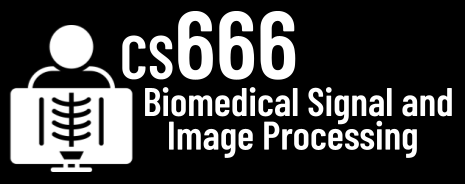
#Assignment 4

In [ ]:
# NAME: SangHyuk Kim

In [ ]:
# In this assignment, we will create a Random Forest classifier to detect pneumonia and covid in xrays!

In [1]:
# load numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# we are using mahotas again, so lets install it!
!pip install mahotas

In [3]:
# our imports include sklearn this time
import mahotas as mh
import os
from sklearn.ensemble import RandomForestClassifier

**Task 1:** Download, extract, and load the data! [15 Points]

In [ ]:
# Please download this file: https://cs666.org/data/xray/ with the wget command!
# Note: Please use the forwarded dropbox link and change dl=0 to dl=1!
# This is a subset of the Kaggle Pneumonia + Covid Datasets!

In [4]:
# Run this code to extract the zip file and to create
# the folder structure of normal/, pneumonia/, and covid/ images.
# Each folder contains the first images of the Kaggle datasets.
# import zipfile
# with zipfile.ZipFile('xray.zip', 'r') as zip_ref:
#     zip_ref.extractall('.')

NORMAL_DIR = 'xray/normal/'
PNEUMONIA_DIR = 'xray/pneumonia/'
COVID_DIR = 'xray/covid/'

In [5]:
# Here we load the first image from the normal dataset.
img = mh.imread(NORMAL_DIR + 'IM-0115-0001.jpeg')

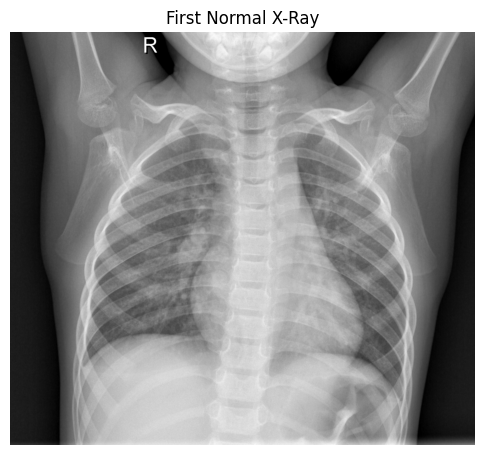

Image dimensions: (1858, 2090)


In [6]:
# TODO: Please display this image and print the dimensions!

# TODO: YOUR CODE

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title("First Normal X-Ray")
plt.axis('off')
plt.show()

print(f"Image dimensions: {img.shape}")

**Task 2:** Let's do some data wrangling and more visualization! [30 Points]

In [7]:
import numpy as np

folders = [NORMAL_DIR, PNEUMONIA_DIR, COVID_DIR]
data = [[],[],[]]

for f_index,f in enumerate( folders ):
  all_files = os.listdir( f )

  data[f_index] = np.zeros( (len(all_files), 300, 300), dtype=np.float32)

  for i in range(len(all_files)):
    loaded_image = mh.imread( f + '/' + all_files[i] )
    if loaded_image.ndim > 2:
      loaded_image = mh.colors.rgb2gray(loaded_image[:,:,:3])

    loaded_image = mh.imresize( loaded_image, (300, 300) )
    img_shape = loaded_image.shape

    data[f_index][ i, 0:img_shape[0], 0:img_shape[1] ] = loaded_image

In [ ]:
# The two code blocks above perform 3 data wrangling operations.
# Which ones?
# Hint: The first two might be more obvious but the third one happens in the
# last line.
# TODO: Operation 1) YOUR ANSWER
# TODO: Operation 2) YOUR ANSWER
# TODO: Operation 3) YOUR ANSWER

#### Operation 1) Grayscale Conversion: The code checks if the image has more than 2 dimensions (e.g., an RGB image). If it does, it converts it into a single-channel 2D grayscale image.

#### Operation 2) It uses ```mahotas.imresize``` with a target of ```(300, 300)```. Crucially, Mahotas preserves the original aspect ratio by scaling the longest dimension to 300 pixels and shrinking the shorter dimension proportionally (e.g., resulting in a 300x150 image), rather than squashing it into a perfect square.

#### Operation 3) Because the resized image might not be exactly ```300x300``` (due to Operation 2), the code slices the exact dimensions of the new image ```(0:img_shape[0], 0:img_shape[1])``` and places it into the top-left corner of a pre-allocated ```300x300``` matrix of zeros. This effectively zero-pads the empty space with black pixels, ensuring all data fed to the model has a uniform shape.

In [ ]:
# Now, let's look at the first 5 normal_images and the first 5 pneumonia_images.
# TODO: Please visualize multiple images at once.
# Hint: You can use one of the following answers from StackOverflow for this:
# https://stackoverflow.com/questions/41210823/using-plt-imshow-to-display-multiple-images

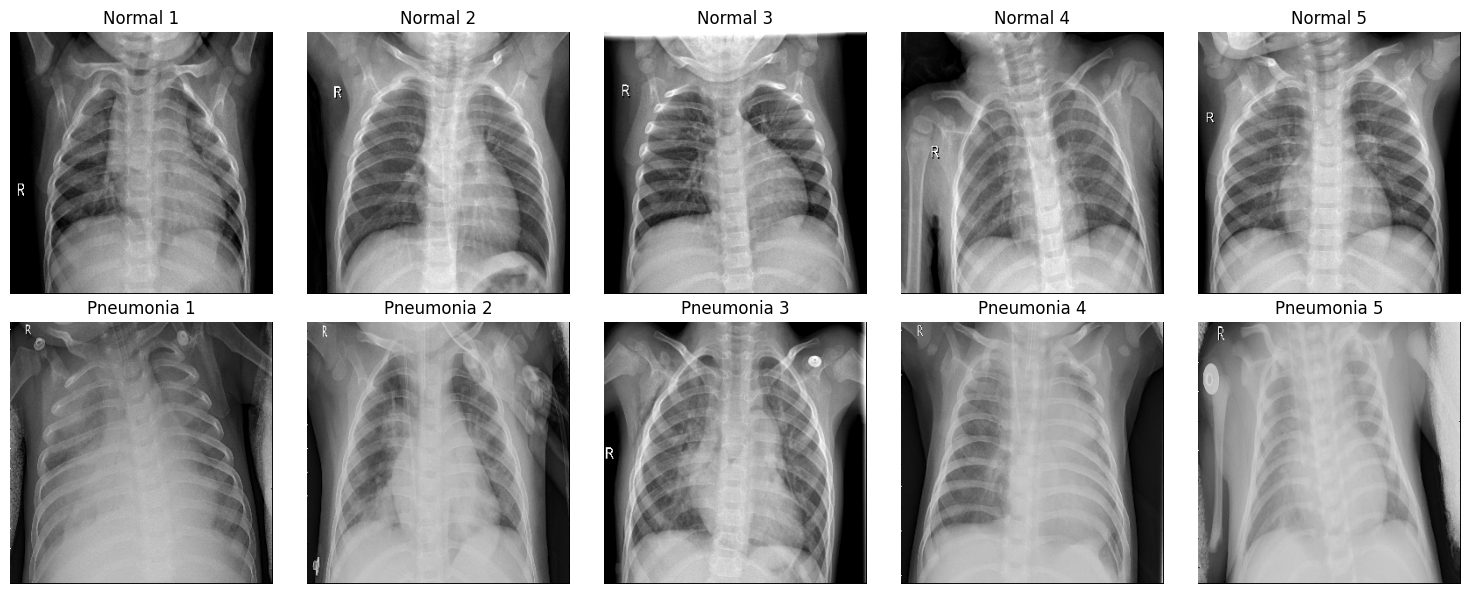

In [8]:
# TODO: YOUR CODE

import matplotlib.pyplot as plt

f, axarr = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    axarr[0, i].imshow(data[0][i], cmap='gray')
    axarr[0, i].set_title(f'Normal {i+1}')
    axarr[0, i].axis('off')
    
    axarr[1, i].imshow(data[1][i], cmap='gray')
    axarr[1, i].set_title(f'Pneumonia {i+1}')
    axarr[1, i].axis('off')

plt.tight_layout()
plt.show()

**Task 3:** Setup training and testing data. [15 Points]

In [ ]:
# Any supervised machine learning algorithm requires disjunct sets of
# training and testing data.
#
# For each, we will create a balanced dataset that includes an equal number
# of normal xrays, pneumonia xrays, and covid xrays.
#
# The training data X_train will include 180 images (60 normal, 60 pneumonia, 60 covid).
# The testing data X_test will include the remaining 120 images (40 normal, 40 pneumonia, 40 covid).
#
# Supervised learning means that we tell the algorithm which image is normal
# and which image is pneumonia. For this, we need the y_train vector.
# The vector shall be 0 for a normal image, and 1 for a pneumonia, and 2 for a covid scan.

In [9]:
TRAINING_COUNT = 60

X_train = np.zeros( (TRAINING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[0:TRAINING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_train[t_pos] = image
    t_pos += 1

In [10]:
# TODO: Please create the y_train vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
# y_train = # TODO

# 60 Normal (0), 60 Pneumonia (1), 60 Covid (2)
y_train = np.array([0]*60 + [1]*60 + [2]*60)

In [11]:
TESTING_COUNT = 40

X_test = np.zeros( (TESTING_COUNT * 3, 300*300 ), dtype=np.float32)
t_pos = 0

for d in data:
  for image in d[TRAINING_COUNT:TRAINING_COUNT+TESTING_COUNT]:
    image = image.ravel() # flatten the image
    image /= image.max() # normalize the image
    X_test[t_pos] = image
    t_pos += 1

In [12]:
# TODO: Please create the y_test vector with 0 for a normal image,
# 1 for a pneumonia, and 2 for covid. This needs to a numpy array.
# y_test = # TODO

# 40 Normal (0), 40 Pneumonia (1), 40 Covid (2)
y_test = np.array([0]*40 + [1]*40 + [2]*40)

**Task 4:** Let's train and evaluate the Random Forest! [30 Points]

In [13]:
# Let's shuffle our training data.
p = np.random.permutation(len(X_train))
X_train = X_train[p]
y_train = y_train[p]

In [17]:
# With scikit-learn, we can easily set up a default Random Forest classifier.
# clf = RandomForestClassifier() --- IGNORE ---
clf = RandomForestClassifier(verbose=2, random_state=42)

In [18]:
# Now, we train the classifier with the training data and the training targets.
# We essentially show the classifier an image and tell whether the image is
# normal or pneumonia or covid.
fitted = clf.fit( X_train, y_train )

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.5s


building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96

[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    1.1s finished


In [ ]:
# TODO: In just a few sentences, please explain how the Random Forest works.

In [ ]:
# TODO: YOUR ANSWER

#### A Random Forest is an ensemble machine learning algorithm that builds a large collection ("forest") of individual decision trees during training. When making a prediction, it feeds the input data through all the trees and outputs the class that receives the majority vote, which prevents the model from overfitting to the training data.

In [19]:
# After training, we can see how well the classifier predicts our testing data.
# The following command will return the classification accuracy.
clf.score( X_test, y_test )

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


0.8916666666666667

In [ ]:
# TODO: Is the classification accuracy good? And, are you surprised?

In [ ]:
# TODO: YOUR ANSWER

#### The classification accuracy is excellent, coming in at approximately 89.16%. This is pretty surprising by how high this score is. Random Forests are traditional machine learning algorithms that look at flattened, 1D arrays of raw pixel intensities; they have no inherent understanding of 2D spatial relationships, shapes, or textures like a Convolutional Neural Network (CNN) would. The fact that it achieved nearly 90% accuracy without any complex feature extraction means that the raw pixel intensity distributions between Normal, Pneumonia, and COVID X-rays are distinctly different enough for the decision trees to separate them.

**Task 5:** Now, let's decrease the number of trees! [10 Points]

In [ ]:
# How many trees are used in Task 4?

In [ ]:
# TODO: YOUR ANSWER

#### By default, the scikit-learn RandomForestClassifier uses 100 trees. Verbose logs also reveal that 100 tress are used by default.

In [ ]:
# Now, please use a single tree and observe the testing performance.

In [20]:
# TODO: YOUR CODE
clf_single = RandomForestClassifier(n_estimators=1, random_state=42, verbose=2)
clf_single.fit(X_train, y_train)

print(f"Accuracy with 1 tree: {clf_single.score(X_test, y_test)}")

building tree 1 of 1
Accuracy with 1 tree: 0.7833333333333333


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


In [ ]:
# Are you surprised?

In [ ]:
# TODO: YOUR ANSWER

#### I am not surprised the performance dropped (Accuracy at around 78%). A single decision tree is highly prone to overfitting the exact training data it was shown. By reducing the forest to one tree, we lose the variance-reduction benefits of the ensemble, leading to poor predictions on new testing data.

**Bonus:** Let's take a closer look! [33 Points]

In [ ]:
# Let's run the fitted classifier on the remaining covid images.
# You might have noticed that there are 199 covid images but we only used 100 so far.
# Please evaluate the classifier on the remaining (previously unseen) 99 covid images
# and check the performance.

In [ ]:
# TODO: YOUR CODE AND YOUR ANSWER

REMAINING = 99
X_bonus = np.zeros((REMAINING, 300*300), dtype=np.float32)

for i, image in enumerate(data[2][100:199]):
    img_flat = image.ravel()
    if img_flat.max() > 0:
        img_flat /= img_flat.max()
    X_bonus[i] = img_flat

y_bonus = np.array([2] * REMAINING)

print(f"Accuracy on unseen COVID images: {clf.score(X_bonus, y_bonus):.2f}")

Accuracy on unseen COVID images: 0.98


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [ ]:
# Can you figure out which images were misclassified?
# Hint: You can use predictions = clf.predict(X_test_covid_only) for this.
# Can you display them?
# Do you have an idea why these images were problematic?

Number of misclassified images: 2


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished


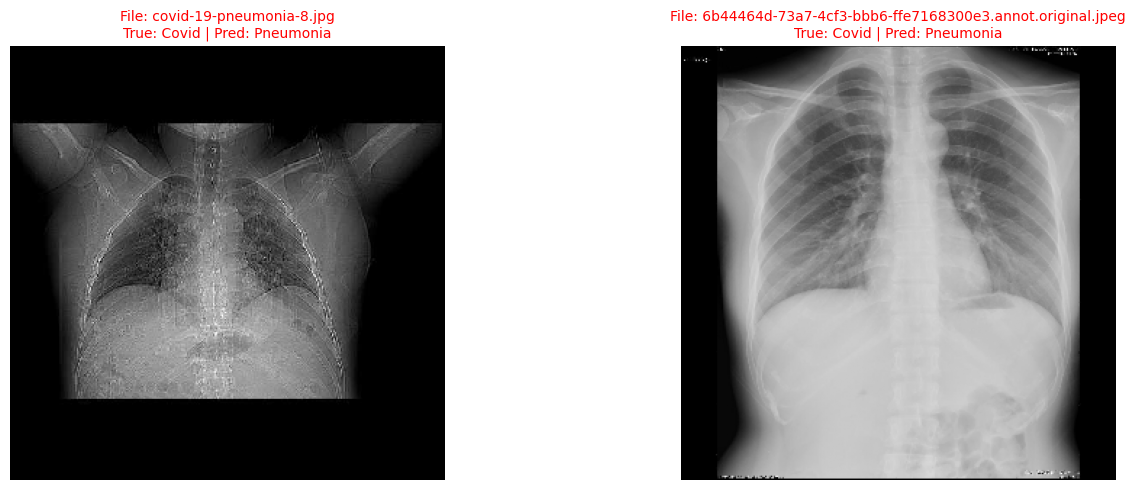

In [26]:
# TODO: YOUR CODE AND YOUR ANSWER

predictions = clf.predict(X_bonus)
misclassified = np.where(predictions != 2)[0]

print(f"Number of misclassified images: {len(misclassified)}")

if len(misclassified) > 0:
    covid_files = os.listdir(COVID_DIR)
    
    display_count = min([5, len(misclassified)])
    f, axarr = plt.subplots(1, display_count, figsize=(15, 5))
    
    if display_count == 1:
        axarr = [axarr]
        
    label_map = {0: 'Normal', 1: 'Pneumonia', 2: 'Covid'}
        
    for ax, idx in zip(axarr, misclassified[:display_count]):
        original_idx = 100 + idx
        ax.imshow(data[2][original_idx], cmap='gray')
        
        true_label = label_map[y_bonus[idx]]
        pred_label = label_map[predictions[idx]]
        filename = covid_files[original_idx] 
        
        ax.set_title(f'File: {filename}\nTrue: {true_label} | Pred: {pred_label}', fontsize=10, color='red')
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

#### The two misclassified COVID-19 X-rays were problematic because the Random Forest evaluates raw pixel intensities without spatial awareness. The first image has dense white opacities that visually mimic general pneumonia, confusing the model's pixel thresholds. The second image has subtle disease indicators and overall darker lung fields resembling a pneunomia scan, which contains medical artifacts that introduce unexpected bright pixels, leading to misclassification to pneunomia instead of COVID-19.

In [ ]:
# Great job!!!
#           ___
#       _.-'   \
#      /        \
#     /          \
#    /            `.___
#   ( .--.)\/(,.--.    `-.
#   ,',-. \   / ,-.`.     )
#  ( /   \     /   \ )   / \
#   || .-|     |-. ||---'|  \
#  _|| | |     | | ||_   |   \
# /. \ |_|.---.|_| / ,\  | .^.\
# `.\ `--"     "--' /,'  |/
#   `>  _________ <'
# ,-' ,---.---.---. `-.
# `--'\    \j/    /`--'
#    `.\         /,'
#      \\_______//
#       `-------'       hjw